In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from PIL import Image
import matplotlib.pyplot as plt

In [3]:
# 원본 이미지와 mask가 저장된 경로
IMAGE_DIR = "/home/bmegpu03/song/1/sample"
MASK_DIR = "/home/bmegpu03/song/1/mask_sample_png"

원본 이미지 파일: ['AP1_10481523.png', 'AP1_10997020.png', 'AP1_11274362.png', 'AP1_11379963.png', 'AP1_11517836.png'] ...
마스크 파일: ['AP1_10481523.png', 'AP1_10997020.png', 'AP1_11274362.png', 'AP1_11379963.png', 'AP1_11517836.png'] ...
총 이미지 쌍의 개수: 182

데이터셋 형태:
X-ray 이미지 배열 형태: (182, 256, 256, 1)
마스크 이미지 배열 형태: (182, 256, 256, 1)


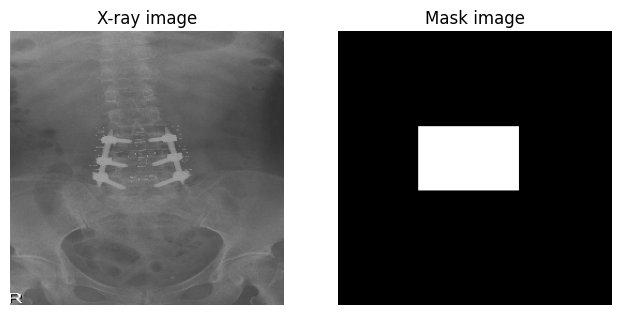


픽셀값 범위:
X-ray 이미지 픽셀 범위: 0.0 ~ 1.0
마스크 이미지 픽셀 범위: 0.0 ~ 1.0


In [4]:
# 이미지 파일 리스트 가져오기 및 정렬
image_files = sorted(os.listdir(IMAGE_DIR))
mask_files = sorted(os.listdir(MASK_DIR))

print("원본 이미지 파일:", image_files[:5], "...")  # 처음 5개 파일명 출력
print("마스크 파일:", mask_files[:5], "...")
print("총 이미지 쌍의 개수:", len(image_files))

# 파일명 일치 여부 확인
if len(image_files) != len(mask_files):
    print("오류: 원본 이미지와 마스크 이미지의 개수가 일치하지 않습니다.")
    print(f"원본 이미지: {len(image_files)}개, 마스크 이미지: {len(mask_files)}개")
    raise Exception("파일 개수 불일치")

for img, mask in zip(image_files, mask_files):
    img_name = os.path.splitext(img)[0]
    mask_name = os.path.splitext(mask)[0]
    if img_name != mask_name:
        print(f"오류: 파일명 불일치 - 원본: {img_name}, 마스크: {mask_name}")
        raise Exception("파일명 불일치")

# 이미지 크기 설정
IMG_HEIGHT = 256
IMG_WIDTH = 256

# 이미지와 마스크를 저장할 배열 초기화
images = []
masks = []

# 이미지 로드 및 전처리
for img_path, mask_path in zip(image_files, mask_files):
    try:
        # X-ray 이미지 로드 및 전처리
        img = load_img(os.path.join(IMAGE_DIR, img_path), 
                      color_mode='grayscale',
                      target_size=(IMG_HEIGHT, IMG_WIDTH))
        img_array = img_to_array(img)
        img_array = (img_array - np.min(img_array)) / (np.max(img_array) - np.min(img_array))  # Min-Max 정규화
        images.append(img_array)
        
        # 마스크 이미지 로드 및 전처리
        mask = load_img(os.path.join(MASK_DIR, mask_path),
                       color_mode='grayscale',
                       target_size=(IMG_HEIGHT, IMG_WIDTH))
        mask_array = img_to_array(mask)
        mask_array = mask_array / 255.0  # 정규화
        masks.append(mask_array)
    except Exception as e:
        print(f"오류: 이미지 로드 중 오류 발생 - {img_path}, {mask_path}")
        print(f"오류 내용: {str(e)}")
        raise

# numpy 배열로 변환
images = np.array(images)
masks = np.array(masks)

print("\n데이터셋 형태:")
print("X-ray 이미지 배열 형태:", images.shape)
print("마스크 이미지 배열 형태:", masks.shape)

# 샘플 이미지와 마스크 시각화
plt.figure(figsize=(12, 4))

# 원본 X-ray 이미지
plt.subplot(131)
plt.imshow(images[0].squeeze(), cmap='gray')
plt.title('X-ray image')
plt.axis('off')

# 마스크 이미지
plt.subplot(132)
plt.imshow(masks[0].squeeze(), cmap='gray')
plt.title('Mask image')
plt.axis('off')

plt.show()

print("\n픽셀값 범위:")
print("X-ray 이미지 픽셀 범위:", images.min(), "~", images.max())
print("마스크 이미지 픽셀 범위:", masks.min(), "~", masks.max())


In [5]:
import torch
torch.cuda.empty_cache()
print(torch.version.cuda)  # PyTorch가 사용하는 CUDA 버전
print(torch.cuda.is_available())  # CUDA 사용 가능 여부
print(torch.cuda.get_device_name(0))  # GPU 이름

12.4
True
NVIDIA GeForce RTX 3080


In [6]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()

        # Encoder (수축 경로)
        self.enc1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck (병목 층)
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder (확장 경로)
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        # 출력층
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Encoder
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool1(enc1))
        enc3 = self.enc3(self.pool2(enc2))
        enc4 = self.enc4(self.pool3(enc3))

        # Bottleneck
        bottleneck = self.bottleneck(self.pool4(enc4))

        # Decoder
        dec4 = self.up4(bottleneck)
        dec4 = torch.cat((enc4, dec4), dim=1)
        dec4 = self.dec4(dec4)

        dec3 = self.up3(dec4)
        dec3 = torch.cat((enc3, dec3), dim=1)
        dec3 = self.dec3(dec3)

        dec2 = self.up2(dec3)
        dec2 = torch.cat((enc2, dec2), dim=1)
        dec2 = self.dec2(dec2)

        dec1 = self.up1(dec2)
        dec1 = torch.cat((enc1, dec1), dim=1)
        dec1 = self.dec1(dec1)

        # 최종 출력
        out = self.final_conv(dec1)
        out = self.sigmoid(out)

        return out

# 모델 초기화
model = UNet(in_channels=1, out_channels=1)
print("모델 구조:")
print(model)


모델 구조:
UNet(
  (enc1): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inp

변환 전 이미지 텐서 형태: torch.Size([182, 256, 256, 1])
변환 전 마스크 텐서 형태: torch.Size([182, 256, 256, 1])

변환된 이미지 텐서 형태: torch.Size([182, 1, 256, 256])
이미지 텐서 타입: torch.float32
이미지 텐서 최소값: -2.427647113800049
이미지 텐서 최대값: 4.251160621643066

변환된 마스크 텐서 형태: torch.Size([182, 1, 256, 256, 1])
마스크 텐서 타입: torch.float32
마스크 텐서 최소값: 0.0
마스크 텐서 최대값: 1.0


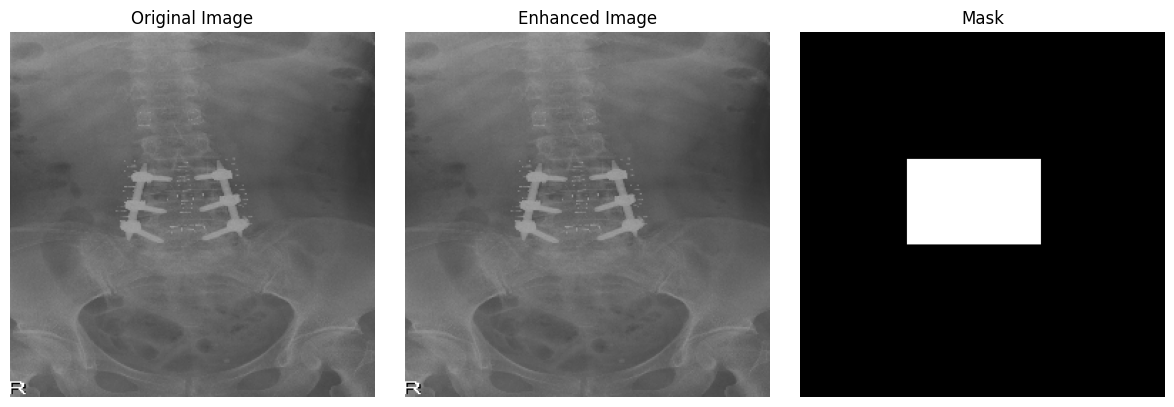

In [7]:
# 필요한 모듈 임포트
import torch
import matplotlib.pyplot as plt

# 이미지와 마스크를 텐서로 변환
image_tensor = torch.from_numpy(images).float()
mask_tensor = torch.from_numpy(masks).float()

# 텐서의 차원 확인
print(f"변환 전 이미지 텐서 형태: {image_tensor.shape}")
print(f"변환 전 마스크 텐서 형태: {mask_tensor.shape}")

# 차원이 5개인 경우 적절히 처리
if len(image_tensor.shape) == 5:
    # 불필요한 차원 제거
    image_tensor = image_tensor.squeeze()
image_tensor = image_tensor.permute(0, 3, 1, 2)  # (B, C, H, W) 형태로 변경

if len(mask_tensor.shape) == 5:
    # 불필요한 차원 제거
    mask_tensor = mask_tensor.squeeze()
mask_tensor = mask_tensor.unsqueeze(1)  # 채널 차원 추가 (B, 1, H, W)

# 이미지 데이터 표준화 - 대비 향상을 위해 수정
mean = image_tensor.mean(dim=(0, 2, 3), keepdim=True)
std = image_tensor.std(dim=(0, 2, 3), keepdim=True)

# 대비 향상을 위한 스케일링 팩터 적용
contrast_scale = 1.5
image_tensor = ((image_tensor - mean) / (std + 1e-7)) * contrast_scale

# 마스크는 이진 분류이므로 0과 1 사이의 값으로 유지
mask_tensor = torch.clamp(mask_tensor, 0, 1)

# 텐서 변환 결과 확인
print(f"\n변환된 이미지 텐서 형태: {image_tensor.shape}")
print(f"이미지 텐서 타입: {image_tensor.dtype}")
print(f"이미지 텐서 최소값: {image_tensor.min()}")
print(f"이미지 텐서 최대값: {image_tensor.max()}")

print(f"\n변환된 마스크 텐서 형태: {mask_tensor.shape}")
print(f"마스크 텐서 타입: {mask_tensor.dtype}")
print(f"마스크 텐서 최소값: {mask_tensor.min()}")
print(f"마스크 텐서 최대값: {mask_tensor.max()}")

# 시각화를 통한 확인
plt.figure(figsize=(12, 4))

# 원본 이미지를 시각화 (첫 번째 이미지 사용)
plt.subplot(1, 3, 1)
plt.imshow(images[0], cmap='gray')  # X-ray 이미지는 그레이스케일로 표시
plt.title('Original Image')
plt.axis('off')

# 텐서로 변환된 이미지를 시각화 (표준화된 이미지를 시각화를 위해 역변환)
plt.subplot(1, 3, 2)
normalized_image = image_tensor[0] * (std[0] / contrast_scale) + mean[0]
plt.imshow(normalized_image.permute(1, 2, 0).numpy(), cmap='gray')
plt.title('Enhanced Image')
plt.axis('off')

# 텐서로 변환된 마스크를 시각화
plt.subplot(1, 3, 3)
plt.imshow(mask_tensor[0, 0].numpy(), cmap='gray')
plt.title('Mask')
plt.axis('off')

# 그래프 품질 향상
plt.tight_layout()
plt.show()

In [8]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ['TORCH_USE_CUDA_DSA'] = '1'

In [9]:
# 필요한 라이브러리 임포트
import torch
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter
import numpy as np
import os

# 하이퍼파라미터 설정
BATCH_SIZE = 8
EPOCHS = 100
LEARNING_RATE = 0.001
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 데이터셋 크기 설정
TRAIN_SIZE = int(0.8 * len(image_tensor))  # 80%를 학습 데이터로 사용
VAL_SIZE = len(image_tensor) - TRAIN_SIZE   # 나머지 20%를 검증 데이터로 사용

# 손실 함수와 옵티마이저 설정
criterion = nn.BCELoss()  # 이진 분류를 위한 Binary Cross Entropy Loss
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"학습 장치: {DEVICE}")
print(f"배치 크기: {BATCH_SIZE}")
print(f"에폭 수: {EPOCHS}")
print(f"학습률: {LEARNING_RATE}")
print(f"학습 데이터 크기: {TRAIN_SIZE}")
print(f"검증 데이터 크기: {VAL_SIZE}")

# 데이터셋 분할
train_images = image_tensor[:TRAIN_SIZE]
train_masks = mask_tensor[:TRAIN_SIZE]
val_images = image_tensor[TRAIN_SIZE:]
val_masks = mask_tensor[TRAIN_SIZE:]

# 데이터셋 생성
train_dataset = torch.utils.data.TensorDataset(train_images, train_masks)
val_dataset = torch.utils.data.TensorDataset(val_images, val_masks)

# 데이터로더 생성
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\n데이터로더 정보:")
print(f"학습 데이터로더 배치 수: {len(train_loader)}")
print(f"검증 데이터로더 배치 수: {len(val_loader)}")

# 모델을 지정된 장치로 이동
model = model.to(DEVICE)
print(f"모델이 {DEVICE}로 이동되었습니다.")

# 모델 학습 모드로 설정
model.train()

# 학습 과정을 기록하기 위한 리스트 초기화
train_losses = []
val_losses = []
best_val_loss = float('inf')

# 조기 종료를 위한 변수 설정
patience = 10  # 검증 손실이 개선되지 않는 것을 참을 에폭 수
patience_counter = 0

# 학습률 스케줄러 설정
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    verbose=True
)

# Dice Loss 구현
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred_flat = pred.view(-1)
        target_flat = target.view(-1)

        intersection = (pred_flat * target_flat).sum()
        dice_score = (2. * intersection + self.smooth) / (
            pred_flat.sum() + target_flat.sum() + self.smooth
        )
        return 1 - dice_score

# 결합된 손실 함수 설정
dice_loss = DiceLoss()
combined_loss = lambda pred, target: 0.5 * criterion(pred, target) + 0.5 * dice_loss(pred, target)

print("학습 준비가 완료되었습니다.")
print("- 손실 함수: BCE Loss + Dice Loss")
print("- 학습률 스케줄러: ReduceLROnPlateau")
print("- 조기 종료 patience:", patience)

# TensorBoard를 위한 로그 디렉토리 설정
log_dir = '/home/bmegpu03/song/1/log'
writer = SummaryWriter(log_dir)
print(f"TensorBoard 로그가 {log_dir}에 저장됩니다.")

# 모델 저장 경로 설정
save_path = '/home/bmegpu03/song/1/model_checkpoint/model_checkpoint_182_8_0.001.pth'

# 모델 저장 디렉토리 생성
os.makedirs(os.path.dirname(save_path), exist_ok=True)

# 모델과 옵티마이저 상태를 딕셔너리 형태로 저장
checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict()
}

try:
    # 모델 저장
    torch.save(checkpoint, save_path)
    print(f'모델이 {save_path}에 저장되었습니다.')
except Exception as e:
    print(f'모델 저장 중 오류 발생: {str(e)}')

# 모델 불러오기 예시 코드
def load_checkpoint(model, optimizer, path):
    try:
        checkpoint = torch.load(path)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        return model, optimizer
    except Exception as e:
        print(f'체크포인트 로딩 중 오류 발생: {str(e)}')
        return model, optimizer

print("저장된 모델은 다음과 같이 불러올 수 있습니다:")
print("model, optimizer = load_checkpoint(model, optimizer, save_path)")

def load_model(save_path, model, optimizer):
    try:
        if not os.path.exists(save_path):  # 저장된 모델이 없는 경우
            print(f'저장된 모델을 찾을 수 없습니다: {save_path}')
            return model, optimizer

        # 체크포인트 불러오기
        checkpoint = torch.load(save_path)

        # 모델과 옵티마이저 상태 불러오기
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

        print(f'모델을 {save_path}에서 성공적으로 불러왔습니다.')
        return model, optimizer
    except Exception as e:
        print(f'모델 로딩 중 오류 발생: {str(e)}')
        return model, optimizer


학습 장치: cuda
배치 크기: 8
에폭 수: 100
학습률: 0.001
학습 데이터 크기: 145
검증 데이터 크기: 37

데이터로더 정보:
학습 데이터로더 배치 수: 19
검증 데이터로더 배치 수: 5
모델이 cuda로 이동되었습니다.
학습 준비가 완료되었습니다.
- 손실 함수: BCE Loss + Dice Loss
- 학습률 스케줄러: ReduceLROnPlateau
- 조기 종료 patience: 10
TensorBoard 로그가 /home/bmegpu03/song/1/log에 저장됩니다.
모델이 /home/bmegpu03/song/1/model_checkpoint/model_checkpoint_182_8_0.001.pth에 저장되었습니다.
저장된 모델은 다음과 같이 불러올 수 있습니다:
model, optimizer = load_checkpoint(model, optimizer, save_path)


/home/bmegpu03/anaconda3/envs/song/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [ ]:
start_epoch = 0
model, optimizer = load_model(save_path, model, optimizer)

# 손실값을 저장할 리스트 초기화
train_losses = []
val_losses = []

for epoch in range(start_epoch + 1, EPOCHS + 1):
    model.train()
    loss_arr = []

    for batch, (inputs, labels) in enumerate(train_loader, 1):
        # forward pass
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)
        # 마지막 차원 제거
        if labels.dim() > 4:
            labels = labels.squeeze(-1)
        outputs = model(inputs)

        # backward pass
        optimizer.zero_grad()
        loss = combined_loss(outputs, labels)
        loss.backward()
        optimizer.step()

        # 손실값 저장
        loss_arr += [loss.item()]

        # TensorBoard에 결과 저장
        if batch % 10 == 0:  # 10 배치마다 저장
            writer.add_images('Train/Input', inputs, epoch * len(train_loader) + batch)
            writer.add_images('Train/Label', labels, epoch * len(train_loader) + batch)
            writer.add_images('Train/Output', outputs, epoch * len(train_loader) + batch)

    epoch_train_loss = np.mean(loss_arr)
    train_losses.append(epoch_train_loss)
    writer.add_scalar('Train/Loss', epoch_train_loss, epoch)

    # 검증
    model.eval()
    val_loss_arr = []

    with torch.no_grad():
        for batch, (inputs, labels) in enumerate(val_loader, 1):
            # forward pass
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            # 마지막 차원 제거
            if labels.dim() > 4:
                labels = labels.squeeze(-1)
            outputs = model(inputs)

            # 손실 계산
            loss = combined_loss(outputs, labels)
            val_loss_arr += [loss.item()]

            print(f'검증: 에폭 {epoch:04d}/{EPOCHS:04d} | 배치 {batch:04d}/{len(val_loader):04d} | 손실 {np.mean(val_loss_arr):.4f}')

            # TensorBoard에 결과 저장
            if batch % 10 == 0:
                writer.add_images('Val/Input', inputs, epoch * len(val_loader) + batch)
                writer.add_images('Val/Label', labels, epoch * len(val_loader) + batch)
                writer.add_images('Val/Output', outputs, epoch * len(val_loader) + batch)

        val_loss = np.mean(val_loss_arr)
        val_losses.append(val_loss)
        writer.add_scalar('Val/Loss', val_loss, epoch)

        # 학습률 조정
        scheduler.step(val_loss)

        # 모델 저장
        checkpoint = {
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch': epoch
        }
        torch.save(checkpoint, save_path)

        # 조기 종료 확인
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'조기 종료: {patience}회 동안 검증 손실이 개선되지 않았습니다.')
                break

writer.close()

# 손실 그래프 그리기
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 학습된 모델 불러오기
checkpoint = torch.load(save_path)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# 테스트 데이터에서 샘플 이미지 가져오기
test_images, test_labels = next(iter(val_loader))
test_images = test_images.to(DEVICE)
test_labels = test_labels.to(DEVICE)
if test_labels.dim() > 4:
    test_labels = test_labels.squeeze(-1)

# 예측 수행
with torch.no_grad():
    predictions = model(test_images)

# CPU로 데이터 이동 및 넘파이 배열로 변환
test_images = test_images.cpu().numpy()
test_labels = test_labels.cpu().numpy()
predictions = predictions.cpu().numpy()

# 시각화
plt.figure(figsize=(10, 4))  # 예시 하나를 보여주기 위해 크기 조정

# 첫 번째 예시 시각화
i = 0

# 입력 이미지
plt.subplot(1, 3, 1)
plt.title('입력 이미지')
plt.imshow(np.transpose(test_images[i], (1, 2, 0)))
plt.axis('off')

# 실제 레이블
plt.subplot(1, 3, 2)
plt.title('실제 레이블')
plt.imshow(test_labels[i, 0], cmap='gray')
plt.axis('off')

# 예측 결과
plt.subplot(1, 3, 3)
plt.title('예측 결과')
plt.imshow(predictions[i, 0], cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


In [7]:
test_dir = "/home/bmegpu03/song/1/test_sample"
tmask_dir = "/home/bmegpu03/song/1/test_sample_png"

In [ ]:
# 이미지 파일 리스트 가져오기 및 정렬

test_dir_files = sorted(os.listdir(test_dir))
test_mask_dir_files = sorted(os.listdir(tmask_dir))

print("원본 이미지 파일:", test_dir_files[:5], "...")  # 처음 5개 파일명 출력
print("총 이미지 쌍의 개수:", len(test_dir_files))
print("마스크 이미지 파일:", test_mask_dir_files[:5], "...")  # 처음 5개 파일명 출력
print("총 이미지 쌍의 개수:", len(test_mask_dir_files))

# 이미지 크기 설정
IMG_HEIGHT = 256
IMG_WIDTH = 256

# 이미지와 마스크를 저장할 배열 초기화
test_images = []
test_masks = []
# 이미지 로드 및 전처리
for test_img_path, test_mask_path in zip(test_dir_files, test_mask_dir_files):
    # X-ray 이미지 로드 및 전처리
    test_img = load_img(os.path.join(test_dir, test_img_path), 
                  color_mode='grayscale',
                  target_size=(IMG_HEIGHT, IMG_WIDTH))
    test_img_array = img_to_array(test_img)
    test_img_array = (test_img_array - np.min(test_img_array)) / (np.max(test_img_array) - np.min(test_img_array))  # Min-Max 정규화
    test_images.append(test_img_array)
    
    # 마스크 이미지 로드 및 전처리
    test_mask = load_img(os.path.join(tmask_dir, test_mask_path),
                   color_mode='grayscale',
                   target_size=(IMG_HEIGHT, IMG_WIDTH))
    test_mask_array = img_to_array(test_mask)
    test_mask_array = test_mask_array / 255.0  # 정규화
    test_masks.append(test_mask_array)
    
# numpy 배열로 변환
test_images = np.array(test_images)
test_masks = np.array(test_masks)

print("\n데이터셋 형태:")
print("X-ray 이미지 배열 형태:", test_images.shape)
print("마스크 이미지 배열 형태:", test_masks.shape)

# 샘플 이미지와 마스크 시각화
plt.figure(figsize=(12, 4))

# 원본 X-ray 이미지
plt.subplot(131)
plt.imshow(test_images[0].squeeze(), cmap='gray')
plt.title('X-ray image')
plt.axis('off')

# 마스크 이미지
plt.subplot(132)
plt.imshow(test_masks[0].squeeze(), cmap='gray')
plt.title('Mask image')
plt.axis('off')

plt.show()

print("\n픽셀값 범위:")
print("X-ray 이미지 픽셀 범위:", test_images.min(), "~", test_images.max())
print("마스크 이미지 픽셀 범위:", test_masks.min(), "~", test_masks.max())
#min(), "~", masks.max())


In [ ]:
# 필요한 모듈 임포트
import torch
import matplotlib.pyplot as plt

# 이미지와 마스크를 텐서로 변환
test_image_tensor = torch.from_numpy(test_images).float()
test_mask_tensor = torch.from_numpy(test_masks).float()

# 텐서의 차원 확인
print(f"변환 전 이미지 텐서 형태: {test_image_tensor.shape}")
print(f"변환 전 마스크 텐서 형태: {test_mask_tensor.shape}")

# 차원이 5개인 경우 적절히 처리
if len(test_image_tensor.shape) == 5:
    # 불필요한 차원 제거
    test_image_tensor = test_image_tensor.squeeze()
test_image_tensor = test_image_tensor.permute(0, 3, 1, 2)  # (B, C, H, W) 형태로 변경

if len(test_mask_tensor.shape) == 5:
    # 불필요한 차원 제거
    test_mask_tensor = test_mask_tensor.squeeze()
test_mask_tensor = test_mask_tensor.unsqueeze(1)  # 채널 차원 추가 (B, 1, H, W)

# 이미지 데이터 표준화 - 대비 향상을 위해 수정
test_mean = test_image_tensor.mean(dim=(0, 2, 3), keepdim=True)
test_std = test_image_tensor.std(dim=(0, 2, 3), keepdim=True)

# 대비 향상을 위한 스케일링 팩터 적용
test_contrast_scale = 1.5
test_image_tensor = ((test_image_tensor - test_mean) / (test_std + 1e-7)) * test_contrast_scale

# 마스크는 이진 분류이므로 0과 1 사이의 값으로 유지
test_mask_tensor = torch.clamp(test_mask_tensor, 0, 1)

# 텐서 변환 결과 확인
print(f"\n변환된 이미지 텐서 형태: {test_image_tensor.shape}")
print(f"이미지 텐서 타입: {test_image_tensor.dtype}")
print(f"이미지 텐서 최소값: {test_image_tensor.min()}")
print(f"이미지 텐서 최대값: {test_image_tensor.max()}")

print(f"\n변환된 마스크 텐서 형태: {test_mask_tensor.shape}")
print(f"마스크 텐서 타입: {test_mask_tensor.dtype}")
print(f"마스크 텐서 최소값: {test_mask_tensor.min()}")
print(f"마스크 텐서 최대값: {test_mask_tensor.max()}")

# 시각화를 통한 확인
plt.figure(figsize=(12, 4))

# 원본 이미지를 시각화 (첫 번째 이미지 사용)
plt.subplot(1, 3, 1)
plt.imshow(test_images[0], cmap='gray')  # X-ray 이미지는 그레이스케일로 표시
plt.title('Original Image')
plt.axis('off')

# 텐서로 변환된 이미지를 시각화 (표준화된 이미지를 시각화를 위해 역변환)
plt.subplot(1, 3, 2)
test_normalized_image = test_image_tensor[0] * (test_std[0] / test_contrast_scale) + test_mean[0]
plt.imshow(test_normalized_image.permute(1, 2, 0).numpy(), cmap='gray')
plt.title('Enhanced Image')
plt.axis('off')

# 텐서로 변환된 마스크를 시각화
plt.subplot(1, 3, 3)
plt.imshow(test_mask_tensor[0, 0].numpy(), cmap='gray')
plt.title('Mask')
plt.axis('off')

# 그래프 품질 향상
plt.tight_layout()
plt.show()

print(test_image_tensor.shape)
print(test_mask_tensor.shape)

In [37]:
test_dir = "/home/bmegpu03/jaebeom/original_images/1/lat_1"

In [38]:
# 이미지 파일 리스트 가져오기 및 정렬
test_dir_files = sorted(os.listdir(test_dir))

print("원본 이미지 파일:", test_dir_files[:5], "...")  # 처음 5개 파일명 출력
print("총 이미지 쌍의 개수:", len(test_dir_files))

# 이미지 크기 설정
IMG_HEIGHT = 256
IMG_WIDTH = 256

# 이미지와 파일명을 저장할 리스트 초기화
test_images = []
image_filenames = []

# 이미지 로드 및 전처리
for test_img_path in test_dir_files:
    # 파일명 저장
    image_filenames.append(test_img_path)
    
    # X-ray 이미지 로드 및 전처리
    test_img = load_img(os.path.join(test_dir, test_img_path), 
                  color_mode='grayscale',
                  target_size=(IMG_HEIGHT, IMG_WIDTH))
    test_img_array = img_to_array(test_img)
    test_img_array = (test_img_array - np.min(test_img_array)) / (np.max(test_img_array) - np.min(test_img_array))  # Min-Max 정규화
    test_images.append(test_img_array)
    
# numpy 배열로 변환
test_images = np.array(test_images)

print("\n데이터셋 형태:")
print("X-ray 이미지 배열 형태:", test_images.shape)

print("\n픽셀값 범위:")
print("X-ray 이미지 픽셀 범위:", test_images.min(), "~", test_images.max())

print("\n저장된 파일명 예시:")
print(image_filenames[:5], "...")


원본 이미지 파일: ['LAT1_17123697.png', 'LAT1_27318181.png', 'LAT1_28610792.png', 'LAT1_29982154.png', 'LAT1_32024993.png'] ...
총 이미지 쌍의 개수: 174

데이터셋 형태:
X-ray 이미지 배열 형태: (174, 256, 256, 1)

픽셀값 범위:
X-ray 이미지 픽셀 범위: 0.0 ~ 1.0

저장된 파일명 예시:
['LAT1_17123697.png', 'LAT1_27318181.png', 'LAT1_28610792.png', 'LAT1_29982154.png', 'LAT1_32024993.png'] ...


In [39]:
# 필요한 모듈 임포트
import torch

# 이미지를 텐서로 변환하고 파일명 리스트 유지
test_image_tensor = torch.from_numpy(test_images).float()
test_filenames = image_filenames  # 파일명 리스트 저장

# 텐서의 차원 확인
print(f"변환 전 이미지 텐서 형태: {test_image_tensor.shape}")

# 차원이 5개인 경우 적절히 처리
if len(test_image_tensor.shape) == 5:
    # 불필요한 차원 제거
    test_image_tensor = test_image_tensor.squeeze()
test_image_tensor = test_image_tensor.permute(0, 3, 1, 2)  # (B, C, H, W) 형태로 변경

# 이미지 데이터 표준화 - 대비 향상을 위해 수정
test_mean = test_image_tensor.mean(dim=(0, 2, 3), keepdim=True)
test_std = test_image_tensor.std(dim=(0, 2, 3), keepdim=True)

# 대비 향상을 위한 스케일링 팩터 적용
test_contrast_scale = 1.5
test_image_tensor = ((test_image_tensor - test_mean) / (test_std + 1e-7)) * test_contrast_scale

# 텐서 변환 결과 확인
print(f"\n변환된 이미지 텐서 형태: {test_image_tensor.shape}")
print(f"이미지 텐서 타입: {test_image_tensor.dtype}")
print(f"이미지 텐서 최소값: {test_image_tensor.min()}")
print(f"이미지 텐서 최대값: {test_image_tensor.max()}")
print(f"파일명 개수: {len(test_filenames)}")

print(test_image_tensor.shape)

변환 전 이미지 텐서 형태: torch.Size([174, 256, 256, 1])

변환된 이미지 텐서 형태: torch.Size([174, 1, 256, 256])
이미지 텐서 타입: torch.float32
이미지 텐서 최소값: -2.33420467376709
이미지 텐서 최대값: 3.4581620693206787
파일명 개수: 174
torch.Size([174, 1, 256, 256])


In [40]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

# 결과 저장 폴더 생성
result_dir = '/home/bmegpu03/song/LAT_1'

# 저장된 모델 불러오기
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
model_path = '/home/bmegpu03/song/best_model.pth'
checkpoint = torch.load(model_path)
model = UNet()  # UNet 모델 인스턴스 생성
model.load_state_dict(checkpoint['model_state_dict'])  # 모델 가중치 불러오기
model = model.to(DEVICE)

# 모델을 평가 모드로 설정
model.eval()

print(test_image_tensor.shape)

# 예측 및 시각화
with torch.no_grad():
    for idx, (input_image, filename) in enumerate(zip(test_image_tensor, test_filenames)):
        # 입력 이미지 준비 (배치 차원 추가)
        input_image = input_image.unsqueeze(0).to(DEVICE)  # [H,W,C] -> [1,H,W,C]
        print(input_image.shape)
        
        # 예측 수행
        output = model(input_image)
        
        # numpy 배열로 변환
        output_np = output.cpu().squeeze().numpy()
        
        # 원본 파일명을 사용하여 결과 저장
        output_filename = os.path.splitext(filename)[0] + '_mask.png'
        plt.imsave(os.path.join(result_dir, output_filename), output_np, cmap='gray')

/tmp/ipykernel_17535/4203650545.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path)


torch.Size([174, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([

In [ ]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

# 결과 저장 폴더 생성
result_dir = '/home/bmegpu03/song/1/result'
if not os.path.exists(result_dir):
    os.makedirs(result_dir)

# IoU 계산 함수 정의
def calculate_iou(pred, target, threshold=0.5):
    pred = (pred > threshold).astype(np.float32)
    target = (target > threshold).astype(np.float32)
    
    intersection = np.logical_and(pred, target)
    union = np.logical_or(pred, target)
    
    iou = np.sum(intersection) / (np.sum(union) + 1e-7)
    return iou

# 모델을 평가 모드로 설정
model.eval()

# IoU 값을 저장할 리스트
total_iou = []

# 마지막 차원(1) 제거
test_mask_tensor = test_mask_tensor.squeeze(-1)

print(test_image_tensor.shape)
print(test_mask_tensor.shape)

# 예측 및 시각화
with torch.no_grad():
    for idx, (input_image, target_mask) in enumerate(zip(test_image_tensor, test_mask_tensor)):
        # 입력 이미지 준비 (배치 차원 추가)
        input_image = input_image.unsqueeze(0).to(DEVICE)  # [H,W,C] -> [1,H,W,C]
        print(input_image.shape)
        
        # 타겟 마스크는 이미 [1, 256, 256] 형태이므로 추가 변환 불필요
        target_mask = target_mask.to(DEVICE)
        print(target_mask.shape)
        # 예측 수행
        output = model(input_image)
        
        # numpy 배열로 변환
        input_np = input_image.cpu().squeeze().numpy()
        output_np = output.cpu().squeeze().numpy()
        target_np = target_mask.cpu().squeeze().numpy()
        
        # IoU 계산
        iou_score = calculate_iou(output_np, target_np)
        total_iou.append(iou_score)
        
        # 결과 시각화
        plt.figure(figsize=(12, 4))
        
        # 입력 이미지
        plt.subplot(1, 3, 1)
        plt.imshow(input_np, cmap='gray')
        plt.title('입력 이미지')
        plt.axis('off')
        
        # 예측 결과
        plt.subplot(1, 3, 2)
        plt.imshow(output_np, cmap='gray')
        plt.title('예측 결과')
        plt.axis('off')
        
        # 정답 마스크
        plt.subplot(1, 3, 3)
        plt.imshow(target_np, cmap='gray')
        plt.title(f'정답 마스크 (IoU: {iou_score:.4f})')
        plt.axis('off')
        
        plt.tight_layout()
        
        # 결과 이미지 저장
        plt.savefig(os.path.join(result_dir, f'result_{idx+1}.png'))
        plt.show()
        
        # 각 이미지 개별 저장
        plt.imsave(os.path.join(result_dir, f'input_{idx+1}.png'), input_np, cmap='gray')
        plt.imsave(os.path.join(result_dir, f'prediction_{idx+1}.png'), output_np, cmap='gray')
        plt.imsave(os.path.join(result_dir, f'target_{idx+1}.png'), target_np, cmap='gray')
        
        print(f"이미지 {idx+1} IoU: {iou_score:.4f}")

# 평균 IoU 출력
mean_iou = np.mean(total_iou)
print(f"\n전체 테스트 데이터의 평균 IoU: {mean_iou:.4f}")

# IoU 결과를 텍스트 파일로 저장
with open(os.path.join(result_dir, 'iou_results.txt'), 'w') as f:
    for idx, iou in enumerate(total_iou):
        f.write(f"이미지 {idx+1} IoU: {iou:.4f}\n")
    f.write(f"\n전체 테스트 데이터의 평균 IoU: {mean_iou:.4f}")
